In [42]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import joblib
from sklearn.metrics import precision_recall_curve, f1_score

In [43]:
# --- CONFIGURATION ---
# Ensure these match your dataset!
NORMAL_LABEL = 1   # Baseline
ANOMALY_LABEL = 2  # Stress

In [44]:
# --- CONFIGURATION ---
# Ensure these match your dataset!
NORMAL_LABEL = 1   # Baseline
ANOMALY_LABEL = 2  # Stress

# --- HELPER 1: SMOOTHING ---
def smooth_errors(loss_array, window_size=5):
    """Applies a simple moving average to the error signal."""
    weights = np.ones(window_size) / window_size
    return np.convolve(loss_array, weights, mode='same')

# --- HELPER 2: F1 OPTIMIZATION (NEW) ---
def find_optimal_threshold(y_true, loss_values):
    """
    Iterates through all possible thresholds to find the one
    that maximizes the F1-Score (Harmonic mean of Precision and Recall).
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, loss_values)
    
    # Calculate F1 for every threshold
    # Note: adding epsilon (1e-10) to avoid division by zero
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    # Get the index of the best score
    best_idx = np.argmax(f1_scores)
    
    return thresholds[best_idx], f1_scores[best_idx]

def evaluate_anomaly_detector():
    print("1. Loading Data & Model...")
    X = np.load('X_data.npy')
    y = np.load('y_data.npy')
    
    # Label Sanity Check
    print(f"Unique labels in y: {np.unique(y)}")
    if NORMAL_LABEL not in y or ANOMALY_LABEL not in y:
        print(f"WARNING: Your data does not contain Label {NORMAL_LABEL} or {ANOMALY_LABEL}. Check your constants!")

    model = tf.keras.models.load_model('gru_autoencoder.h5')
    
    # --- STEP 1.5: APPLY SCALING ---
    print("Loading Scaler and normalizing data...")
    try:
        scaler = joblib.load('guardian_scaler.pkl')
        
        # Flatten -> Transform -> Reshape
        num_features = X.shape[2]
        X_flat = X.reshape(-1, num_features)
        X_scaled_flat = scaler.transform(X_flat)
        X_scaled = X_scaled_flat.reshape(X.shape)
        
    except FileNotFoundError:
        print("ERROR: 'guardian_scaler.pkl' not found! Run training first.")
        return

    # --- 2. Get Reconstructions ---
    print("Reconstructing data...")
    reconstructions = model.predict(X_scaled)
    
    # --- 3. Calculate Error ---
    train_loss = np.mean(np.abs(reconstructions - X_scaled), axis=(1,2))
    
    # --- SMOOTHING ---
    print("Applying Temporal Smoothing...")
    train_loss = smooth_errors(train_loss, window_size=10)

    # ============================================================
    # --- STEP 4: DETERMINE OPTIMAL THRESHOLD (F1-Score) ---
    # ============================================================
    print("Optimizing Threshold for F1-Score...")
    
    # 1. Filter data: Keep only Normal and Stress for evaluation
    mask = np.isin(y, [NORMAL_LABEL, ANOMALY_LABEL])
    y_filtered = y[mask]
    loss_filtered = train_loss[mask]
    
    # 2. Convert to Binary (0=Normal, 1=Anomaly)
    y_binary = np.where(y_filtered == ANOMALY_LABEL, 1, 0)
    
    # 3. Find the best threshold automatically
    best_thresh, best_f1 = find_optimal_threshold(y_binary, loss_filtered)
    
    print(f"Optimal Threshold Found: {best_thresh:.4f}")
    print(f"Max F1-Score: {best_f1:.4f}")
    
    # Set the threshold for the final report
    threshold = best_thresh
    # ============================================================
    
    # --- 5. Classify ---
    # We apply this threshold to the filtered data we just prepared
    preds = (loss_filtered > threshold).astype(int)
    
    # --- 6. Metrics ---
    print("\n--- RESULTS ---")
    print(f"Accuracy:  {accuracy_score(y_binary, preds):.4f}")
    print(f"Precision: {precision_score(y_binary, preds):.4f}")
    print(f"Recall:    {recall_score(y_binary, preds):.4f}")
    
    cm = confusion_matrix(y_binary, preds)
    print("\nConfusion Matrix:")
    print(cm)
    
    # --- 7. Visualization ---
    # Separate losses for plotting based on original labels
    normal_loss_plot = train_loss[y == NORMAL_LABEL]
    anomaly_loss_plot = train_loss[y == ANOMALY_LABEL]
    
    plt.figure(figsize=(10, 6))
    sns.histplot(normal_loss_plot, bins=50, alpha=0.6, label='Normal (Baseline)', color='blue', kde=True)
    sns.histplot(anomaly_loss_plot, bins=50, alpha=0.6, label='Anomaly (Stress)', color='red', kde=True)
    plt.axvline(threshold, color='k', linestyle='--', label=f'Threshold ({threshold:.3f})')
    plt.title(f"Reconstruction Error (F1-Optimized)")
    plt.xlabel("Reconstruction Error (MAE)")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

1. Loading Data & Model...
Unique labels in y: [1 2 3 4]
Loading Scaler and normalizing data...
Reconstructing data...
46/46 [==============================] - 6s 92ms/step
Applying Temporal Smoothing...
Optimizing Threshold for F1-Score...
Optimal Threshold Found: 0.1138
Max F1-Score: 1.0000

--- RESULTS ---
Accuracy:  0.9989
Precision: 1.0000
Recall:    0.9967

Confusion Matrix:
[[572   0]
 [  1 306]]


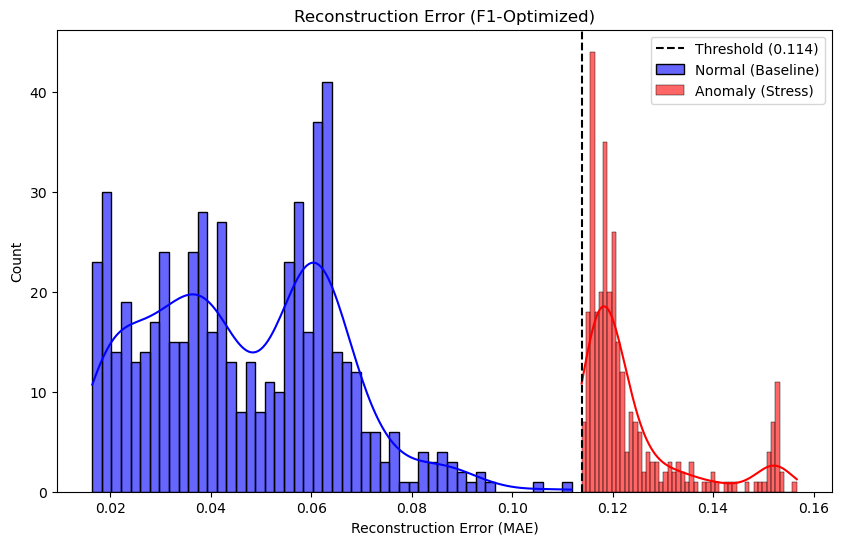

In [45]:
if __name__ == "__main__":
    evaluate_anomaly_detector()